In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = "https://raw.githubusercontent.com/gastonstat/CreditScoring/master/CreditScoring.csv"

In [3]:
!wget $data

--2026-02-27 01:47:35--  https://raw.githubusercontent.com/gastonstat/CreditScoring/master/CreditScoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182489 (178K) [text/plain]
Saving to: ‘CreditScoring.csv.1’

CreditScoring.csv.1 100%[===================>] 178.21K  --.-KB/s    in 0.1s    

2026-02-27 01:47:35 (1.53 MB/s) - ‘CreditScoring.csv.1’ saved [182489/182489]



In [4]:
df = pd.read_csv(data)

In [5]:
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [6]:
df.columns = df.columns.str.lower()

In [7]:
df.status.value_counts()

status
1    3200
2    1254
0       1
Name: count, dtype: int64

In [8]:
status_values = {
    1:'ok',
    2:'default',
    0:'unk'
}
df.status = df.status.map(status_values)

home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}
df.home = df.home.map(home_values)
 
marital_values = {
    1: 'single', 
    2: 'married', 
    3: 'widow', 
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}
df.marital = df.marital.map(marital_values)
 
records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}
df.records = df.records.map(records_values)
 
job_values = {
    1: 'fixed', 
    2: 'partime', 
    3: 'freelance', 
    4: 'others',
    0: 'unk'
}
df.job = df.job.map(job_values)
 
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [9]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [10]:
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)

In [11]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [12]:
df[df.status != 'unk'].reset_index(drop = True)

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449,default,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4450,ok,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4451,default,0,owner,24,37,married,no,partime,60,90.0,3500.0,0.0,500,963
4452,ok,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


In [13]:
df = df[df.status != 'unk'].reset_index(drop = True)

In [14]:
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449,default,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4450,ok,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4451,default,0,owner,24,37,married,no,partime,60,90.0,3500.0,0.0,500,963
4452,ok,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


### Uptill now we did data cleaning 
    ->column names lowercase kiya
    ->Based on R files (which I dont have), we will see that categoriacal columns have numerical values, they should be given their correct values to make them more meaningful
    ->So we replace values like 0,1,2,3,4 with correct names. 0 is unknown
    ->We check numerical columns now. 9999999 is used for unknown values, we replace it with NaN.
    ->We had one unkown values in our target column, we should remove that data point itself to keep the target column binary (1,2). We dont do so for other unknown values.

In [15]:
from sklearn.model_selection import train_test_split

In [177]:
df_full_train, df_test = train_test_split(df, test_size = 0.2, random_state = 11)

In [17]:
df_train, df_val = train_test_split(df_full_train, test_size = 0.25, random_state = 11)

In [18]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [19]:
y_train = (df_train.status == 'default').astype('int').values

In [20]:
y_train = (df_train.status == 'default').astype('int').values
y_val = (df_val.status == 'default').astype('int').values
y_test = (df_test.status == 'default').astype('int').values

In [21]:
y_train

array([1, 1, 0, ..., 0, 0, 0], shape=(2672,))

In [22]:
del df_train['status']
del df_val['status']
del df_test['status']

In [23]:
df_train

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,10,owner,36,36,married,no,freelance,75,0.0,10000.0,0.0,1000,1400
1,6,parents,48,32,single,yes,fixed,35,85.0,0.0,0.0,1100,1330
2,1,parents,48,40,married,no,fixed,75,121.0,0.0,0.0,1320,1600
3,1,parents,48,23,single,no,partime,35,72.0,0.0,0.0,1078,1079
4,5,owner,36,46,married,no,freelance,60,100.0,4000.0,0.0,1100,1897
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2667,18,private,36,45,married,no,fixed,45,220.0,20000.0,0.0,800,1600
2668,7,private,60,29,married,no,fixed,60,51.0,3500.0,500.0,1000,1290
2669,1,parents,24,19,single,no,fixed,35,28.0,0.0,0.0,400,600
2670,15,owner,48,43,married,no,freelance,60,100.0,18000.0,0.0,2500,2976


In [24]:
from sklearn.tree import DecisionTreeClassifier

In [25]:
from sklearn.feature_extraction import DictVectorizer

In [26]:
from sklearn.metrics import roc_auc_score

In [27]:
df_train = df_train.fillna(0)

In [28]:
df_train.to_dict(orient = "records")

[{'seniority': 10,
  'home': 'owner',
  'time': 36,
  'age': 36,
  'marital': 'married',
  'records': 'no',
  'job': 'freelance',
  'expenses': 75,
  'income': 0.0,
  'assets': 10000.0,
  'debt': 0.0,
  'amount': 1000,
  'price': 1400},
 {'seniority': 6,
  'home': 'parents',
  'time': 48,
  'age': 32,
  'marital': 'single',
  'records': 'yes',
  'job': 'fixed',
  'expenses': 35,
  'income': 85.0,
  'assets': 0.0,
  'debt': 0.0,
  'amount': 1100,
  'price': 1330},
 {'seniority': 1,
  'home': 'parents',
  'time': 48,
  'age': 40,
  'marital': 'married',
  'records': 'no',
  'job': 'fixed',
  'expenses': 75,
  'income': 121.0,
  'assets': 0.0,
  'debt': 0.0,
  'amount': 1320,
  'price': 1600},
 {'seniority': 1,
  'home': 'parents',
  'time': 48,
  'age': 23,
  'marital': 'single',
  'records': 'no',
  'job': 'partime',
  'expenses': 35,
  'income': 72.0,
  'assets': 0.0,
  'debt': 0.0,
  'amount': 1078,
  'price': 1079},
 {'seniority': 5,
  'home': 'owner',
  'time': 36,
  'age': 46,
  'm

In [29]:
train_dicts = df_train.to_dict(orient = "records")

In [30]:
dv = DictVectorizer(sparse = False)
X_train = dv.fit_transform(train_dicts)

In [31]:
dv.get_feature_names_out()

array(['age', 'amount', 'assets', 'debt', 'expenses', 'home=ignore',
       'home=other', 'home=owner', 'home=parents', 'home=private',
       'home=rent', 'home=unk', 'income', 'job=fixed', 'job=freelance',
       'job=others', 'job=partime', 'job=unk', 'marital=divorced',
       'marital=married', 'marital=separated', 'marital=single',
       'marital=unk', 'marital=widow', 'price', 'records=no',
       'records=yes', 'seniority', 'time'], dtype=object)

In [32]:
df_train.isna().sum()

seniority    0
home         0
time         0
age          0
marital      0
records      0
job          0
expenses     0
income       0
assets       0
debt         0
amount       0
price        0
dtype: int64

In [33]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [34]:
df_val = df_val.fillna(0)

In [35]:
val_dicts = df_val.to_dict(orient = 'records')

In [36]:
X_val = dv.transform(val_dicts)

In [37]:
y_pred= dt.predict_proba(X_val)[:,1]

In [38]:
y_pred

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0.,
       0., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0.,
       0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0.,
       1., 0., 0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 0., 1., 0., 1.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.,
       0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1.,
       1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 0., 0.

In [39]:
roc_auc_score(y_val, y_pred)

0.657180136107142

Lets check on training dataset

In [40]:
y_pred= dt.predict_proba(X_train)[:,1]

In [41]:
roc_auc_score(y_train, y_pred)

1.0

On training data, AUC is 1, but on validation data its .64. This is called overfitting

We will control depth of the tree using (max_depth = 4)

In [42]:
dt = DecisionTreeClassifier(max_depth = 4)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [43]:
y_pred= dt.predict_proba(X_train)[:,1]
auc = roc_auc_score(y_train, y_pred)
print('train:', auc)

y_pred= dt.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_pred)
print('val:', auc)

train: 0.8164293560926146
val: 0.7612827250490422


In [44]:
from sklearn.tree import export_text

In [45]:
print(export_text(dt, feature_names = dv.get_feature_names_out()))

|--- records=no <= 0.50
|   |--- seniority <= 6.50
|   |   |--- amount <= 862.50
|   |   |   |--- seniority <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- seniority >  0.50
|   |   |   |   |--- class: 0
|   |   |--- amount >  862.50
|   |   |   |--- assets <= 8250.00
|   |   |   |   |--- class: 1
|   |   |   |--- assets >  8250.00
|   |   |   |   |--- class: 0
|   |--- seniority >  6.50
|   |   |--- income <= 103.50
|   |   |   |--- assets <= 4500.00
|   |   |   |   |--- class: 1
|   |   |   |--- assets >  4500.00
|   |   |   |   |--- class: 0
|   |   |--- income >  103.50
|   |   |   |--- expenses <= 89.00
|   |   |   |   |--- class: 0
|   |   |   |--- expenses >  89.00
|   |   |   |   |--- class: 1
|--- records=no >  0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- assets <= 4250.00
|   |   |   |   |--- class: 0
|   |   |   |--- assets >  4250.00
|   |   |   |   |--- class: 0
|   |   |--- income >  74.50
|   |   |   |--- seniority <= 5.50
|   | 

In [46]:
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449,default,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4450,ok,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4451,default,0,owner,24,37,married,no,partime,60,90.0,3500.0,0.0,500,963
4452,ok,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


# 6.5 Decision Tree Parameter tuning

- Selecting max_depth  
- Selecting min_samples_leaf

Tree has multiple parameters, two impoertant ones are:  
- Max-depth
- how we decide if a leave is sufficently large and not pure. It is the minimum number of samples that must exist in a leaf node after a split.

In [47]:
for d in [1,3,4,5,6,10,15,20, None]:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)

    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    print(f'Depth {d}-> AUC:{auc:.3f}')

Depth 1-> AUC:0.606
Depth 3-> AUC:0.739
Depth 4-> AUC:0.761
Depth 5-> AUC:0.766
Depth 6-> AUC:0.758
Depth 10-> AUC:0.681
Depth 15-> AUC:0.667
Depth 20-> AUC:0.653
Depth None-> AUC:0.648


Depth 4,5 and 6 give best results.

We tested for 4,5 and 6.  
Later we tested for [4,5,6,10,15,20, None] again

In [48]:
scores = []
for d in [4,5,6,10,15,20, None]:
    for s in [1,2,3,5,10,15,20,100,200,500]:
        dt = DecisionTreeClassifier(max_depth=d,min_samples_leaf=s)
        dt.fit(X_train, y_train)
    
        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((d,s,round(auc, 3)))
    


In [49]:
scores

[(4, 1, 0.761),
 (4, 2, 0.761),
 (4, 3, 0.761),
 (4, 5, 0.761),
 (4, 10, 0.761),
 (4, 15, 0.764),
 (4, 20, 0.761),
 (4, 100, 0.756),
 (4, 200, 0.747),
 (4, 500, 0.68),
 (5, 1, 0.766),
 (5, 2, 0.767),
 (5, 3, 0.767),
 (5, 5, 0.768),
 (5, 10, 0.762),
 (5, 15, 0.772),
 (5, 20, 0.774),
 (5, 100, 0.763),
 (5, 200, 0.759),
 (5, 500, 0.68),
 (6, 1, 0.748),
 (6, 2, 0.755),
 (6, 3, 0.748),
 (6, 5, 0.762),
 (6, 10, 0.778),
 (6, 15, 0.785),
 (6, 20, 0.773),
 (6, 100, 0.776),
 (6, 200, 0.768),
 (6, 500, 0.68),
 (10, 1, 0.691),
 (10, 2, 0.709),
 (10, 3, 0.721),
 (10, 5, 0.733),
 (10, 10, 0.766),
 (10, 15, 0.788),
 (10, 20, 0.784),
 (10, 100, 0.78),
 (10, 200, 0.768),
 (10, 500, 0.68),
 (15, 1, 0.658),
 (15, 2, 0.696),
 (15, 3, 0.698),
 (15, 5, 0.724),
 (15, 10, 0.762),
 (15, 15, 0.787),
 (15, 20, 0.783),
 (15, 100, 0.78),
 (15, 200, 0.768),
 (15, 500, 0.68),
 (20, 1, 0.659),
 (20, 2, 0.695),
 (20, 3, 0.703),
 (20, 5, 0.715),
 (20, 10, 0.76),
 (20, 15, 0.786),
 (20, 20, 0.784),
 (20, 100, 0.78),
 (2

In [50]:
columns = ['max-depth', 'leaf', 'AUC']
df_scores = pd.DataFrame(scores, columns = columns)

In [51]:
df_scores

,max-depth,leaf,AUC
0,4.0,1,0.761
1,4.0,2,0.761
2,4.0,3,0.761
3,4.0,5,0.761
4,4.0,10,0.761
...,...,...,...
65,NaN,15,0.789
66,NaN,20,0.782
67,NaN,100,0.780
68,NaN,200,0.768


In [52]:
df_scores.sort_values(by = 'AUC', ascending = False).head()

,max-depth,leaf,AUC
65,NaN,15,0.789
35,10.0,15,0.788
45,15.0,15,0.787
55,20.0,15,0.786
25,6.0,15,0.785


In [53]:
df_scores_pivot = df_scores.pivot(columns=['leaf'], index=['max-depth'], values=['AUC'])
df_scores_pivot

AUC                                                              
leaf         1      2      3      5      10     15     20     100    200   500
max-depth                                                                     
NaN        0.653  0.693  0.702  0.719  0.760  0.789  0.782  0.780  0.768  0.68
4.0        0.761  0.761  0.761  0.761  0.761  0.764  0.761  0.756  0.747  0.68
5.0        0.766  0.767  0.767  0.768  0.762  0.772  0.774  0.763  0.759  0.68
6.0        0.748  0.755  0.748  0.762  0.778  0.785  0.773  0.776  0.768  0.68
10.0       0.691  0.709  0.721  0.733  0.766  0.788  0.784  0.780  0.768  0.68
15.0       0.658  0.696  0.698  0.724  0.762  0.787  0.783  0.780  0.768  0.68
20.0       0.659  0.695  0.703  0.715  0.760  0.786  0.784  0.780  0.768  0.68

<Axes: xlabel='None-leaf', ylabel='max-depth'>

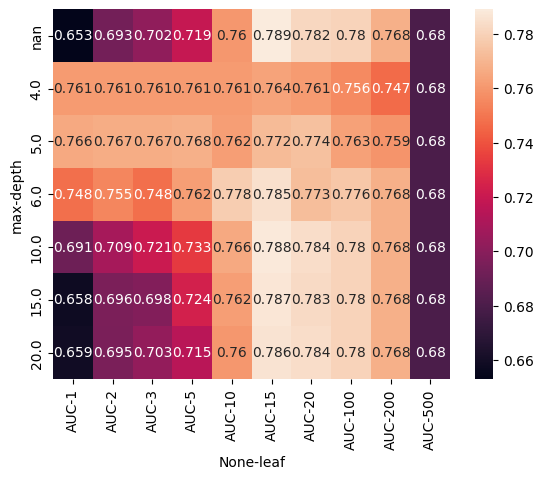

In [54]:
sns.heatmap(df_scores_pivot, annot=True, fmt=".3g" )

In [55]:
dt = DecisionTreeClassifier(max_depth=6,min_samples_leaf=10)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

# 6.6  Ensembles and random Forest

In [56]:
from sklearn.ensemble import RandomForestClassifier

In [57]:
rf = RandomForestClassifier(n_estimators=10, random_state = 1)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

n_estimators=10  
The random forest will build 10 decision trees.

In [58]:
y_pred = rf.predict_proba(X_val)[:, 1]

In [59]:
roc_auc_score(y_val,y_pred)

0.7744726453706618

In [60]:
rf.predict_proba(X_val[[0]])[:, 1]

array([0.1])

in abouve code it is Using all the features (columns) but For one customer (one row). Every time we train rf, rf.predict_proba change the value because  
Each time you train:
- Different bootstrap samples  
- Different feature splits  
- Different trees  
So prediction changes slightly.

To eliminate this randomness, we will give seed, random_state = 1, and then we will get a statble value

Lets check performance of the model for different n_estimators values

In [61]:
scores=[]
for n in range(10,201,10):
    rf = RandomForestClassifier(n_estimators=n, random_state = 1)
    rf.fit(X_train,y_train)
    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val,y_pred)
    scores.append((n,auc))

    

In [62]:
df_scores = pd.DataFrame(scores, columns = ['n_estimators', 'auc'])

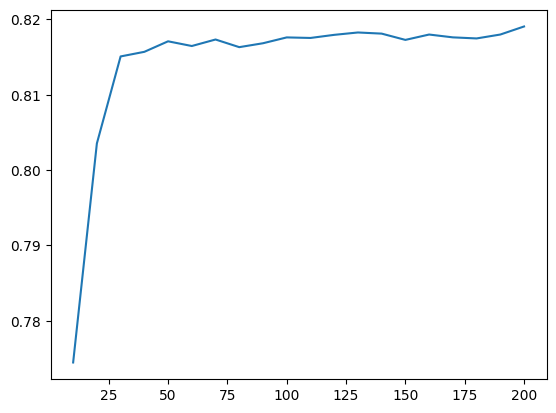

In [63]:
plt.plot(df_scores.n_estimators, df_scores.auc)

AUC improves till 50 trees, after that it is stagnant.  
I should define n =50 here, but we will do at the end

We will now to prameter tuning for Random forest like we did for decision trees. We tune the same parameters in Random Forest because they are made up of decision trees

In [64]:
scores=[]
for d in [5,10,15]:
    for n in range(10,201,10):
        rf = RandomForestClassifier(n_estimators=n, 
                                    max_depth = d, 
                                    random_state = 1)
        rf.fit(X_train,y_train)
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val,y_pred)
        scores.append((d,n,auc))


In [65]:
columns = ['max_depth','n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns = columns)
df_scores

,max_depth,n_estimators,auc
0,5,10,0.787699
1,5,20,0.797731
2,5,30,0.800305
3,5,40,0.799708
4,5,50,0.799878
5,5,60,0.801167
6,5,70,0.802251
7,5,80,0.803244
8,5,90,0.803616
9,5,100,0.804452


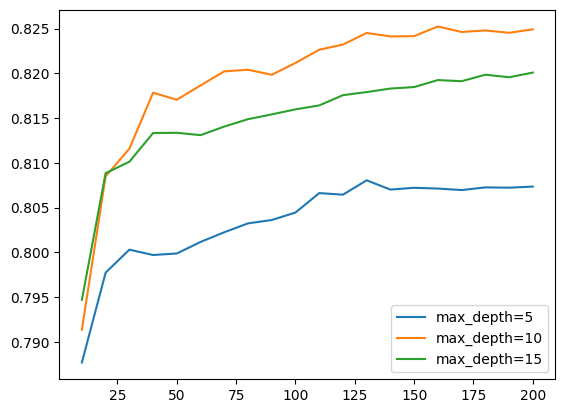

In [66]:
for d in [5,10,15]:
    df_subset = df_scores[df_scores.max_depth ==d]
    plt.plot(df_subset.n_estimators, df_subset.auc, label=f"max_depth={d}")
plt.legend()

In [67]:
max_depth = 10

In [68]:
scores=[]
for s in [1,3,5,10,50]:
    for n in range(10,201,10):
        rf = RandomForestClassifier(n_estimators=n, 
                                    max_depth =max_depth,
                                    min_samples_leaf=s,
                                    random_state = 1)
        rf.fit(X_train,y_train)
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val,y_pred)
        scores.append((s,n,auc))

In [69]:
columns = ['min_samples_leaf','n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns = columns)
df_scores

,min_samples_leaf,n_estimators,auc
0,1,10,0.791365
1,1,20,0.808496
2,1,30,0.811584
3,1,40,0.817839
4,1,50,0.817058
...,...,...,...
95,50,160,0.805929
96,50,170,0.805172
97,50,180,0.805324
98,50,190,0.805596


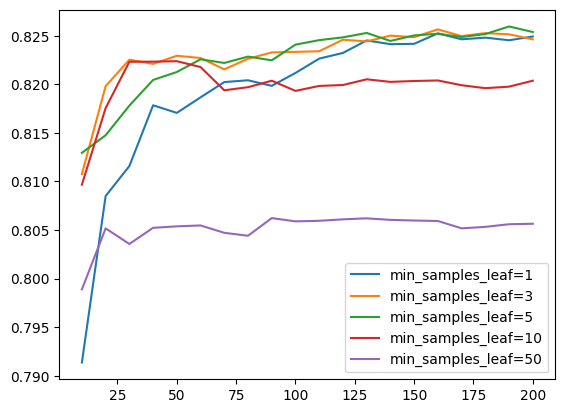

In [70]:
for s in [1,3,5,10,50]:
    df_subset = df_scores[df_scores.min_samples_leaf ==s]
    plt.plot(df_subset.n_estimators, df_subset.auc, label=f"min_samples_leaf={s}")
plt.legend()

In [71]:
min_samples_leaf = 3

We will re-train our random forest with  new parameters

In [72]:
n=50

In [73]:
rf = RandomForestClassifier(n_estimators=n, 
                            max_depth =max_depth,
                            min_samples_leaf=min_samples_leaf,
                            random_state = 1)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

Other useful parameter:  
- Max_features
- bootstrap

Now I will combile the decision tries in a different way, here trees we train were independent of each other, we train them parallel. There is different way to train them sequntially. Each model connects arrows of previous model. This way of combinig model is called boosting. We use XGboost.

In [74]:
import xgboost as xgb

In [75]:
dv.get_feature_names_out().tolist()

['age',
 'amount',
 'assets',
 'debt',
 'expenses',
 'home=ignore',
 'home=other',
 'home=owner',
 'home=parents',
 'home=private',
 'home=rent',
 'home=unk',
 'income',
 'job=fixed',
 'job=freelance',
 'job=others',
 'job=partime',
 'job=unk',
 'marital=divorced',
 'marital=married',
 'marital=separated',
 'marital=single',
 'marital=unk',
 'marital=widow',
 'price',
 'records=no',
 'records=yes',
 'seniority',
 'time']

In [76]:
features = dv.get_feature_names_out().tolist()
dtrain = xgb.DMatrix(X_train, label = y_train,  feature_names= features)
dval = xgb.DMatrix(X_val, label = y_val,  feature_names= features)

In [77]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'nthred': 8,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain, num_boost_round=10)

/usr/local/python/3.12.1/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [02:07:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "nthred" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [78]:
y_pred = model.predict(dval)

In [79]:
roc_auc_score(y_val, y_pred)

0.8118506454190986

In [80]:
watchlist = [(dtrain, 'train'), (dval, 'val')]


In [81]:
%%capture output

xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 4,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain,
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [82]:
print(output.stdout)

[0]	train-auc:0.86653	val-auc:0.77999
[5]	train-auc:0.92969	val-auc:0.80822
[10]	train-auc:0.95512	val-auc:0.81115
[15]	train-auc:0.96767	val-auc:0.81993
[20]	train-auc:0.97648	val-auc:0.81877
[25]	train-auc:0.98248	val-auc:0.81520
[30]	train-auc:0.98844	val-auc:0.81613
[35]	train-auc:0.99244	val-auc:0.81453
[40]	train-auc:0.99393	val-auc:0.81407
[45]	train-auc:0.99568	val-auc:0.81392
[50]	train-auc:0.99723	val-auc:0.81276
[55]	train-auc:0.99804	val-auc:0.81299
[60]	train-auc:0.99861	val-auc:0.81244
[65]	train-auc:0.99916	val-auc:0.81197
[70]	train-auc:0.99962	val-auc:0.81243
[75]	train-auc:0.99975	val-auc:0.81152
[80]	train-auc:0.99989	val-auc:0.81359
[85]	train-auc:0.99993	val-auc:0.81193
[90]	train-auc:0.99998	val-auc:0.81038
[95]	train-auc:0.99999	val-auc:0.80871
[100]	train-auc:0.99999	val-auc:0.80842
[105]	train-auc:1.00000	val-auc:0.80778
[110]	train-auc:1.00000	val-auc:0.80764
[115]	train-auc:1.00000	val-auc:0.80722
[120]	train-auc:1.00000	val-auc:0.80750
[125]	train-auc:1.0000

In [83]:
s = output.stdout

In [84]:
output.stdout.strip().split('\n')

['[0]\ttrain-auc:0.86653\tval-auc:0.77999',
 '[5]\ttrain-auc:0.92969\tval-auc:0.80822',
 '[10]\ttrain-auc:0.95512\tval-auc:0.81115',
 '[15]\ttrain-auc:0.96767\tval-auc:0.81993',
 '[20]\ttrain-auc:0.97648\tval-auc:0.81877',
 '[25]\ttrain-auc:0.98248\tval-auc:0.81520',
 '[30]\ttrain-auc:0.98844\tval-auc:0.81613',
 '[35]\ttrain-auc:0.99244\tval-auc:0.81453',
 '[40]\ttrain-auc:0.99393\tval-auc:0.81407',
 '[45]\ttrain-auc:0.99568\tval-auc:0.81392',
 '[50]\ttrain-auc:0.99723\tval-auc:0.81276',
 '[55]\ttrain-auc:0.99804\tval-auc:0.81299',
 '[60]\ttrain-auc:0.99861\tval-auc:0.81244',
 '[65]\ttrain-auc:0.99916\tval-auc:0.81197',
 '[70]\ttrain-auc:0.99962\tval-auc:0.81243',
 '[75]\ttrain-auc:0.99975\tval-auc:0.81152',
 '[80]\ttrain-auc:0.99989\tval-auc:0.81359',
 '[85]\ttrain-auc:0.99993\tval-auc:0.81193',
 '[90]\ttrain-auc:0.99998\tval-auc:0.81038',
 '[95]\ttrain-auc:0.99999\tval-auc:0.80871',
 '[100]\ttrain-auc:0.99999\tval-auc:0.80842',
 '[105]\ttrain-auc:1.00000\tval-auc:0.80778',
 '[110]\tt

In [85]:
line = s.split('\n')[0]

In [86]:
num_iter, train_auc, val_auc =line.split('\t')

In [87]:
int(num_iter.strip('[]'))

0

In [88]:
float(train_auc.split(':')[1])

0.86653

In [89]:
float(val_auc.split(':')[1])

0.77999

Lets write a fucntion to do this

In [90]:
def parse_xgb_output(output):
    results = []
    tree = []
    aucs_train = []
    aucs_val = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))
    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns = columns)

    return df_results

In [91]:
df_scores = parse_xgb_output(output)

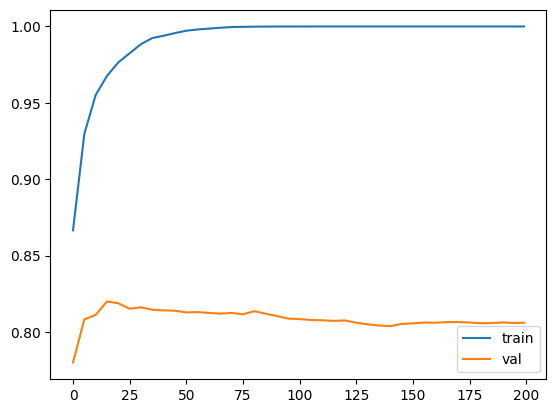

In [92]:
plt.plot(df_scores.num_iter, df_scores.train_auc, label = 'train')
plt.plot(df_scores.num_iter, df_scores.val_auc, label = 'val')
plt.legend()

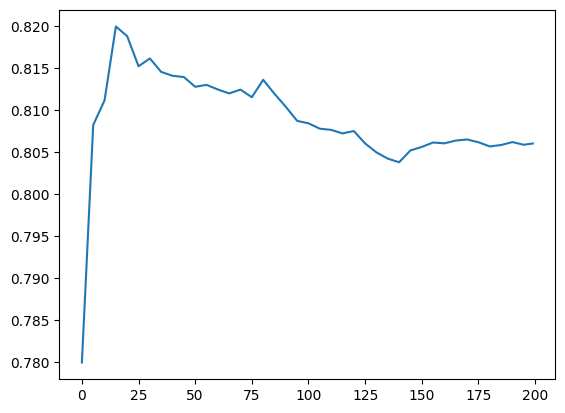

In [93]:
plt.plot(df_scores.num_iter, df_scores.val_auc, label = 'val')

Till here we did with default parameters, we will now tune the parameters

We will tune eta, max_depth and min_child_weight

In [94]:
scores = {}

In [119]:
%%capture output

xgb_params = {
    'eta': 0.05,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 4,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain,
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [120]:
f"eta={xgb_params['eta']}"

'eta=0.05'

In [121]:
key = f"eta={xgb_params['eta']}"
scores[key] = parse_xgb_output(output)

In [122]:
scores

{'eta=0.1':     num_iter  train_auc  val_auc
 0          0    0.86653  0.77999
 1          5    0.90462  0.79276
 2         10    0.91936  0.80573
 3         15    0.93128  0.81241
 4         20    0.94007  0.81551
 5         25    0.94698  0.81664
 6         30    0.95175  0.81942
 7         35    0.95668  0.82229
 8         40    0.96125  0.82243
 9         45    0.96437  0.82507
 10        50    0.96869  0.82559
 11        55    0.97260  0.82630
 12        60    0.97493  0.82736
 13        65    0.97720  0.82745
 14        70    0.97937  0.82631
 15        75    0.98202  0.82728
 16        80    0.98397  0.82811
 17        85    0.98547  0.82747
 18        90    0.98770  0.82851
 19        95    0.98899  0.82775
 20       100    0.99024  0.82711
 21       105    0.99133  0.82714
 22       110    0.99222  0.82692
 23       115    0.99295  0.82652
 24       120    0.99392  0.82615
 25       125    0.99476  0.82706
 26       130    0.99532  0.82555
 27       135    0.99575  0.82576
 28

In [123]:
scores.keys()

dict_keys(['eta=0.1', 'eta=0.3', 'eta=0.5', 'eta=0.05'])

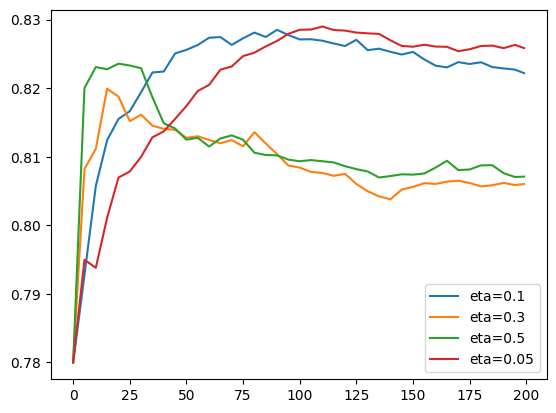

In [124]:
for key, df_scores in scores.items():
    plt.plot(df_scores.num_iter, df_scores.val_auc, label = key)
plt.legend()

In [125]:
scores

{'eta=0.1':     num_iter  train_auc  val_auc
 0          0    0.86653  0.77999
 1          5    0.90462  0.79276
 2         10    0.91936  0.80573
 3         15    0.93128  0.81241
 4         20    0.94007  0.81551
 5         25    0.94698  0.81664
 6         30    0.95175  0.81942
 7         35    0.95668  0.82229
 8         40    0.96125  0.82243
 9         45    0.96437  0.82507
 10        50    0.96869  0.82559
 11        55    0.97260  0.82630
 12        60    0.97493  0.82736
 13        65    0.97720  0.82745
 14        70    0.97937  0.82631
 15        75    0.98202  0.82728
 16        80    0.98397  0.82811
 17        85    0.98547  0.82747
 18        90    0.98770  0.82851
 19        95    0.98899  0.82775
 20       100    0.99024  0.82711
 21       105    0.99133  0.82714
 22       110    0.99222  0.82692
 23       115    0.99295  0.82652
 24       120    0.99392  0.82615
 25       125    0.99476  0.82706
 26       130    0.99532  0.82555
 27       135    0.99575  0.82576
 28

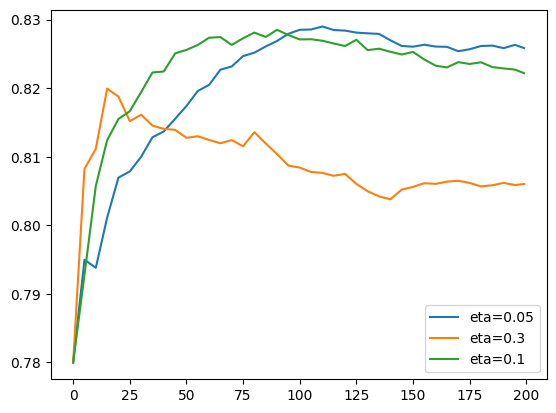

In [126]:
etas = ['eta=0.05', 'eta=0.3', 'eta=0.1']

for eta in etas:
    df_scores = scores[eta]
    plt.plot(df_scores.num_iter, df_scores.val_auc, label = eta)
plt.legend()

So 0.1 is performing best.  
eta = 0.1  
Max_depth will be ssame as random forest's max depth.  
Min_child_weight  will be approx equal to min_sample-leaf

Let tune max_depth

In [128]:
scores = {}

In [138]:
%%capture output

xgb_params = {
    'eta': 0.1,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 4,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain,
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [139]:
key = f"max_depth={xgb_params['max_depth']}"
scores[key] = parse_xgb_output(output)
key

'max_depth=6'

In [135]:
scores

{'max_depth=3':     num_iter  train_auc  val_auc
 0          0    0.77610  0.73891
 1          5    0.83058  0.77600
 2         10    0.85036  0.79448
 3         15    0.85993  0.80317
 4         20    0.86898  0.80852
 5         25    0.87768  0.81474
 6         30    0.88186  0.81747
 7         35    0.88619  0.81957
 8         40    0.88961  0.82042
 9         45    0.89281  0.82407
 10        50    0.89673  0.82755
 11        55    0.89964  0.82759
 12        60    0.90252  0.82725
 13        65    0.90552  0.82771
 14        70    0.90859  0.82809
 15        75    0.91031  0.82813
 16        80    0.91216  0.82920
 17        85    0.91443  0.83015
 18        90    0.91623  0.83121
 19        95    0.91794  0.83059
 20       100    0.91922  0.83093
 21       105    0.92055  0.83121
 22       110    0.92290  0.83152
 23       115    0.92394  0.83091
 24       120    0.92517  0.83134
 25       125    0.92652  0.83184
 26       130    0.92785  0.83193
 27       135    0.92848  0.83182

In [141]:
del scores['max_depth=10']

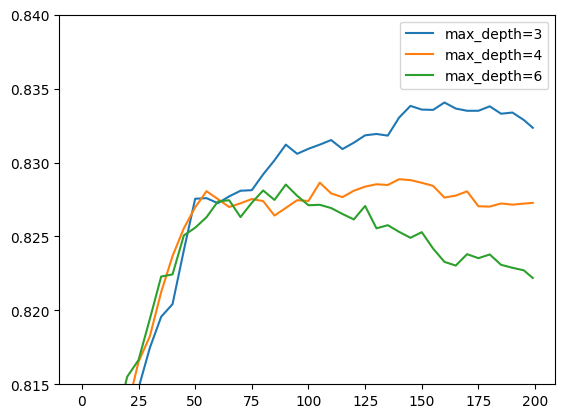

In [143]:
for max_depth, df_scores in scores.items():
    plt.plot(df_scores.num_iter, df_scores.val_auc, label = max_depth)
plt.ylim(0.815,0.84)
plt.legend()

So we conclude that.  
max_depth = 3 is best

Now lets tune Min_child_weight

In [144]:
scores = {}

In [151]:
%%capture output

xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 30,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 4,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain,
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [152]:
key = f"min_child_weight={xgb_params['min_child_weight']}"
scores[key] = parse_xgb_output(output)
key

'min_child_weight=30'

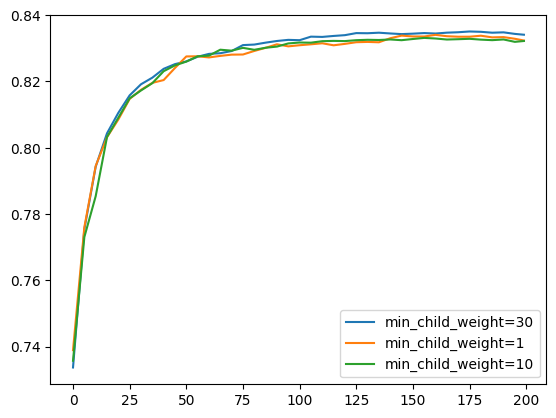

In [153]:
for min_child_weight, df_scores in scores.items():
    plt.plot(df_scores.num_iter, df_scores.val_auc, label = min_child_weight)

plt.legend()

this parameter is not worth experimenting in this case so we will take..  
min_child_weight = 1 (default)

Also lets train our model for 175 iterations. So..
num_boost_round = 175

Below is our final model

In [154]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 4,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain, num_boost_round=175,)

Other useful parameters:

- `subsample` and `colsample_bytree`
- `lambda` and `alpha`

So we have trained 3 models, Decison trees, Random Forest, XGBoost, we will pick the best one

### Decision Tree

In [155]:
dt = DecisionTreeClassifier(max_depth=6,min_samples_leaf=10)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [159]:
y_pred= dt.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_pred)
auc

0.7778026688624642

### Random Forest

In [156]:
rf = RandomForestClassifier(n_estimators=50, 
                            max_depth =10,
                            min_samples_leaf=3,
                            random_state = 1)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [160]:
y_pred= rf.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_pred)
auc

0.8229365963527162

### XGBoot

In [157]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 4,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain, num_boost_round=175,)

In [161]:
y_pred= model.predict(dval)
auc = roc_auc_score(y_val, y_pred)
auc

0.8334715797631446

We compared all thre models and XGBoost is best one.

Now lets train full dataset for XGBoost

In [178]:
df_full_train=df_full_train.reset_index(drop=True)

In [184]:
y_full_train = (df_full_train.status=='default').astype(int).values

In [186]:
del df_full_train['status']

In [199]:
dicts_full_train = df_full_train.to_dict(orient = 'records')

In [206]:
dv=DictVectorizer(sparse=False)

X_full_train = dv.fit_transform(dicts_full_train)

In [207]:
dicts_test = df_test.to_dict(orient = 'records')
X_test = dv.transform(dicts_test)

In [208]:
 dfulltrain = xgb.DMatrix(X_full_train, 
                          label = y_full_train, 
                          feature_names = dv.get_feature_names_out().tolist())

 dtest = xgb.DMatrix(X_test,
                     feature_names = dv.get_feature_names_out().tolist())

In [209]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthread': 4,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dfulltrain, num_boost_round=175,)

In [210]:
y_pred= model.predict(dtest)
auc = roc_auc_score(y_test, y_pred)
auc

0.8299814280826938

XGBoost performed reasonalbly good on the test dataset